In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
data=pd.read_csv("medical_insurance.csv")

In [7]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [33]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [17]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [36]:
pd.get_dummies(data,columns=['smoker','region','children','sex'],drop_first=True)

,age,bmi,charges,smoker_yes,region_northwest,region_southeast,region_southwest,children_1,children_2,children_3,children_4,children_5,sex_male
0,19,27.900,16884.92400,1,0,0,1,0,0,0,0,0,0
1,18,33.770,1725.55230,0,0,1,0,1,0,0,0,0,1
2,28,33.000,4449.46200,0,0,1,0,0,0,1,0,0,1
3,33,22.705,21984.47061,0,1,0,0,0,0,0,0,0,1
4,32,28.880,3866.85520,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2767,47,45.320,8569.86180,0,0,1,0,1,0,0,0,0,0
2768,21,34.600,2020.17700,0,0,0,1,0,0,0,0,0,0
2769,19,26.030,16450.89470,1,1,0,0,1,0,0,0,0,1
2770,23,18.715,21595.38229,0,1,0,0,0,0,0,0,0,1


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,Xtest,y_train,y_test=train_test_split(data.iloc[:,0:6],data.iloc[:,-1])

In [69]:
X_train.shape

(2079, 6)

In [70]:
Xtest.shape

(693, 6)

In [14]:
##from sklearn.preprocessing import OrdinalEncoder

In [37]:
from sklearn.preprocessing import OneHotEncoder


In [40]:
ohe=OneHotEncoder(sparse=False,dtype=np.int32,drop='first')

In [43]:
X_train_new=ohe.fit_transform(X_train[['smoker','region','sex','children']])
X_train_new

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [45]:
X_test_new=ohe.transform(Xtest[['smoker','region','sex','children']])


In [48]:
np.hstack((X_train[['age','bmi']].values,X_train_new))

array([[28.   , 28.88 ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [20.   , 31.92 ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [42.   , 32.87 ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       ...,
       [21.   , 16.815,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [64.   , 25.6  ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [27.   , 45.9  ,  0.   , ...,  0.   ,  0.   ,  0.   ]])

In [94]:
X_train.shape

(2079, 6)

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [103]:
transformer=ColumnTransformer(transformers=[('OHE',OneHotEncoder(sparse=False,drop='first'),['sex','region']),
                                                 ('Ordinal',OrdinalEncoder(categories=[['no','yes']]),['smoker']),
                                           ('Scaling',StandardScaler(),['age','bmi','children'])],remainder='passthrough')
## remainder is for rest of the col other than tranformation taking cols

In [104]:
X_train_processed=transformer.fit_transform(X_train)
X_train_processed.shape

(2079, 8)

In [105]:
X_test_processed=transformer.transform(Xtest)
X_test_processed.shape

(693, 8)

In [106]:
X_train_processed

array([[ 0.        ,  0.        ,  0.        , ..., -0.78877218,
        -0.29851029, -0.09474872],
       [ 0.        ,  1.        ,  0.        , ..., -1.35838961,
         0.20263931, -0.90872639],
       [ 0.        ,  0.        ,  0.        , ...,  0.20805831,
         0.35924856, -0.90872639],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -1.28718743,
        -2.28744775, -0.09474872],
       [ 1.        ,  0.        ,  0.        , ...,  1.77450624,
        -0.83922433,  0.71922895],
       [ 1.        ,  0.        ,  0.        , ..., -0.85997436,
         2.50726805,  0.71922895]])

In [108]:
##features_names=transformer.get_feature_names_out()

In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Setup the models in a dictionary (easy to loop through)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 2. Train and Evaluate
print(f"{'Model':<20} | {'R2 Score':<10} | {'MAE':<10}")
print("-" * 45)

for name, model in models.items():
    # Train
    model.fit(X_train_processed, y_train)
    
    # Predict
    y_pred = model.predict(X_test_processed)
    
    # Evaluate
    score = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{name:<20} | {score:.4f}     | {mae:.2f}")

Model                | R2 Score   | MAE       
---------------------------------------------
Linear Regression    | 0.7692     | 4055.95
Decision Tree        | 0.9183     | 846.20
Random Forest        | 0.9407     | 1441.31


True Top Driver: smoker


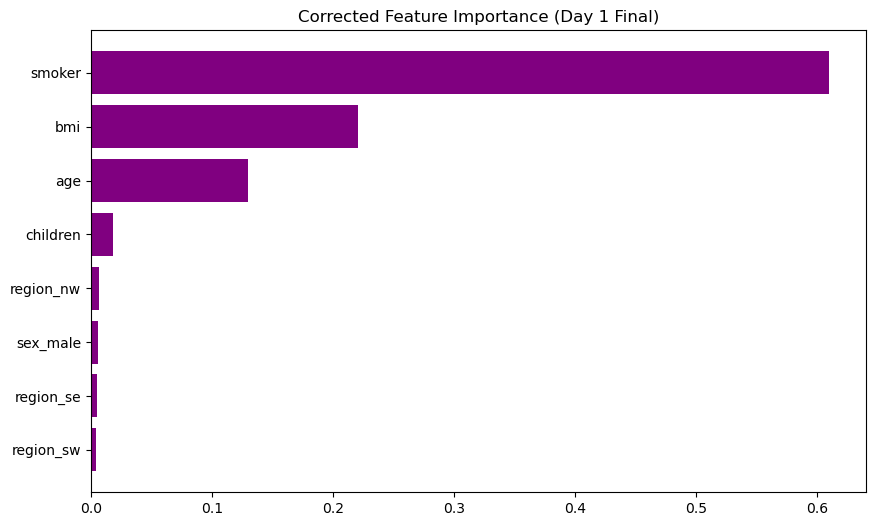

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the correct order based on YOUR ColumnTransformer
# [Sex(1), Region(3)] -> [Smoker(1)] -> [Age, BMI, Children(3)]
feature_names_corrected = [
    'sex_male',        # Index 0
    'region_nw',       # Index 1
    'region_se',       # Index 2
    'region_sw',       # Index 3
    'smoker',          # Index 4 ( The Real MVP )
    'age',             # Index 5
    'bmi',             # Index 6
    'children'         # Index 7
]

# 2. Get Importances
importances = models['Random Forest'].feature_importances_

# 3. Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_corrected,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot
print("True Top Driver:", feature_importance_df.iloc[0]['Feature'])

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='purple')
plt.gca().invert_yaxis()
plt.title("Corrected Feature Importance (Day 1 Final)")
plt.show()

In [111]:
new_person = {
    'age': [30],
    'sex': ['male'],
    'bmi': [25.0],
    'children': [0],
    'smoker': ['no'],
    'region': ['southwest']
}

# 2. Convert to DataFrame
new_df = pd.read_json(pd.DataFrame(new_person).to_json()) # trick to match formats or just pd.DataFrame(new_person)
new_df = pd.DataFrame(new_person)

# 3. Pass it through the PIPELINE
# (Crucial: Use the pipeline, NOT just the model, so it applies the scaling/encoding automatically)
# Assuming 'pipe' is your trained pipeline object
prediction = pipe.predict(new_df)

print(f"Predicted Insurance Bill: ${prediction[0]:.2f}")

NameError: name 'pipe' is not defined